In [1]:
# Auto-reload modules during development
%load_ext autoreload
%autoreload 2

import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt

# Import the framework
from nowkit.nowcasting_framework import (
    NowcastConfig,
    DataManager,
    ModelManager,
    EvaluationManager,
    VisualizationManager,
    InferencePipeline
)

# Import model
from sklearn.tree import DecisionTreeRegressor

## 1. Configuration

In [2]:
# Configure Decision Tree experiment
# Using 10-model ensemble to average stochastic outputs
config = NowcastConfig(
    target_variable="gdpc1",
    test_start_date="2005-03-01",
    test_end_date="2010-03-01",
    n_lags=4,
    n_ensemble_models=10,  # Average 10 models due to stochasticity
    quarterly_only=True
)

print("Decision Tree Configuration:")
print("=" * 60)
for key, value in config.to_dict().items():
    print(f"{key:20s}: {value}")
print("=" * 60)

Decision Tree Configuration:
target              : gdpc1
test_period         : 2005-03-01 to 2010-03-01
lags                : [-2, -1, 0, 1, 2]
n_lags              : 4
n_ensemble          : 10


## 2. Data Loading

In [3]:
# Initialize and load data
data_manager = DataManager(config)
data_manager.load_data().prepare_test_data()

# Display data summary
data_manager.summary()

✓ Loaded data: (913, 25)
✓ Loaded metadata: (24, 8)
✓ Test data prepared: 21 periods


,Metric,Value
0,Total Observations,913
1,Test Periods,21
2,Variables,24
3,Target Variable,gdpc1
4,Missing in Target (%),66.9%


## 3. Model Training and Backtesting

In [4]:
# Configure Decision Tree parameters
dt_params = {
    'criterion': 'absolute_error',
    'max_depth': None,
    'min_samples_split': 0.05,
    'min_samples_leaf': 0.02
}

# Create model manager and run backtest
dt_model = ModelManager(DecisionTreeRegressor, dt_params, config)
dt_model.run_backtest(data_manager)


Running backtest with 10 ensemble model(s)...
  Processing 5/21 dates...
  Processing 5/21 dates...
  Processing 10/21 dates...
  Processing 10/21 dates...
  Processing 15/21 dates...
  Processing 15/21 dates...
  Processing 20/21 dates...
  Processing 20/21 dates...
✓ Backtest complete: 21 periods processed
✓ Backtest complete: 21 periods processed


## 4. Evaluation

In [5]:
# Evaluate model performance
evaluator = EvaluationManager()
evaluator.add_model_results(
    'Decision Tree (10-ensemble)',
    dt_model.get_predictions(),
    data_manager.actuals,
    config.lags
)

# Display performance metrics
print("\nPERFORMANCE BY VINTAGE:")
print("-" * 60)
display(evaluator.get_performance_table().round(6))

print("\n" + evaluator.summary_report())


PERFORMANCE BY VINTAGE:
------------------------------------------------------------


Model,Vintage,Decision Tree (10-ensemble)
0,-2,0.008971
1,-1,0.008989
2,0,0.008552
3,1,0.007865
4,2,0.005983



MODEL EVALUATION SUMMARY

Model: Decision Tree (10-ensemble)
  Average RMSE across vintages: 0.008072
  Best vintage: lag=2 (RMSE=0.005983)



## 5. Visualization

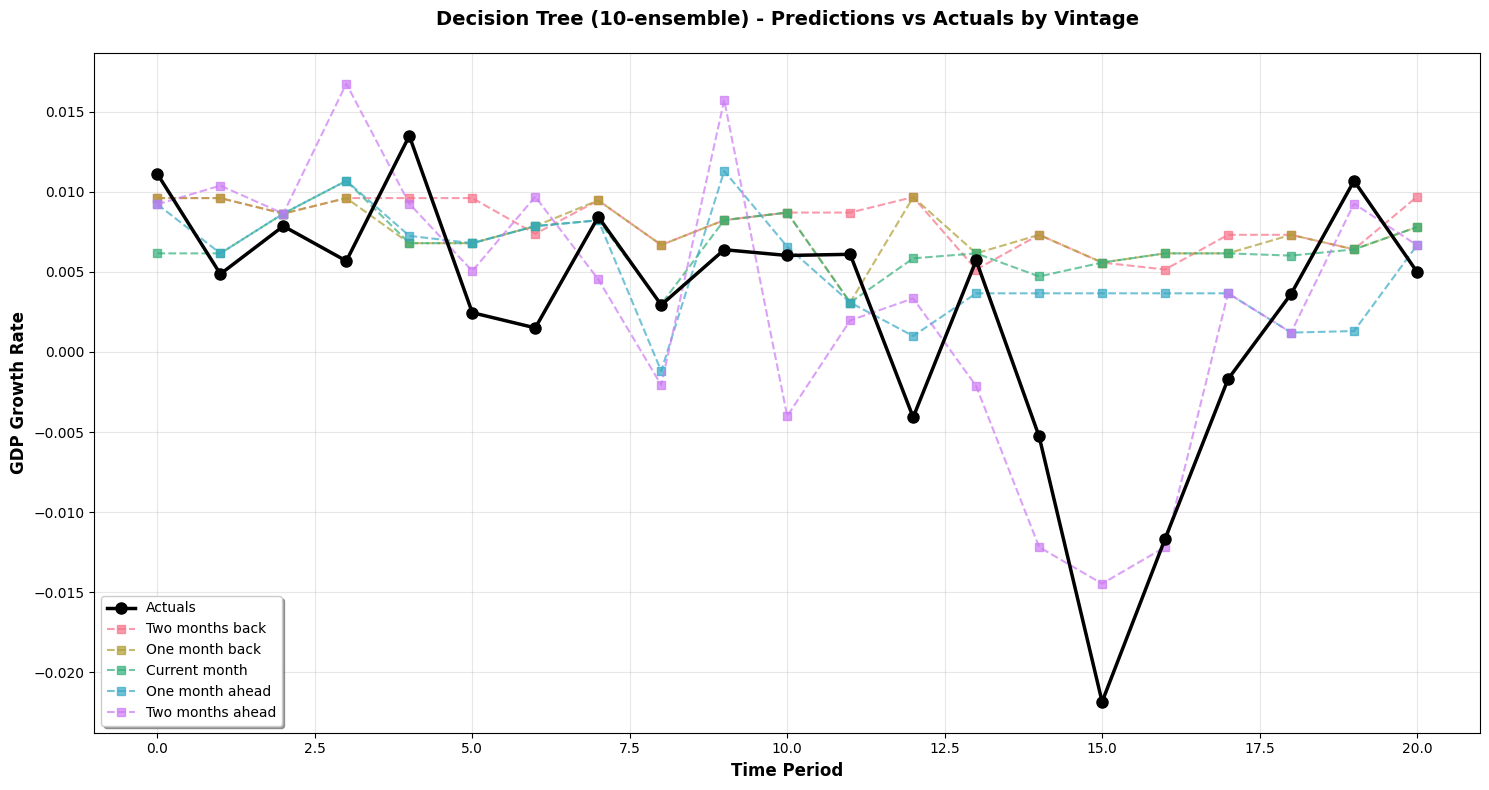

In [6]:
# Create visualization manager
viz = VisualizationManager(evaluator)

# Plot predictions vs actuals
fig1 = viz.plot_predictions_vs_actuals('Decision Tree (10-ensemble)')
plt.show()

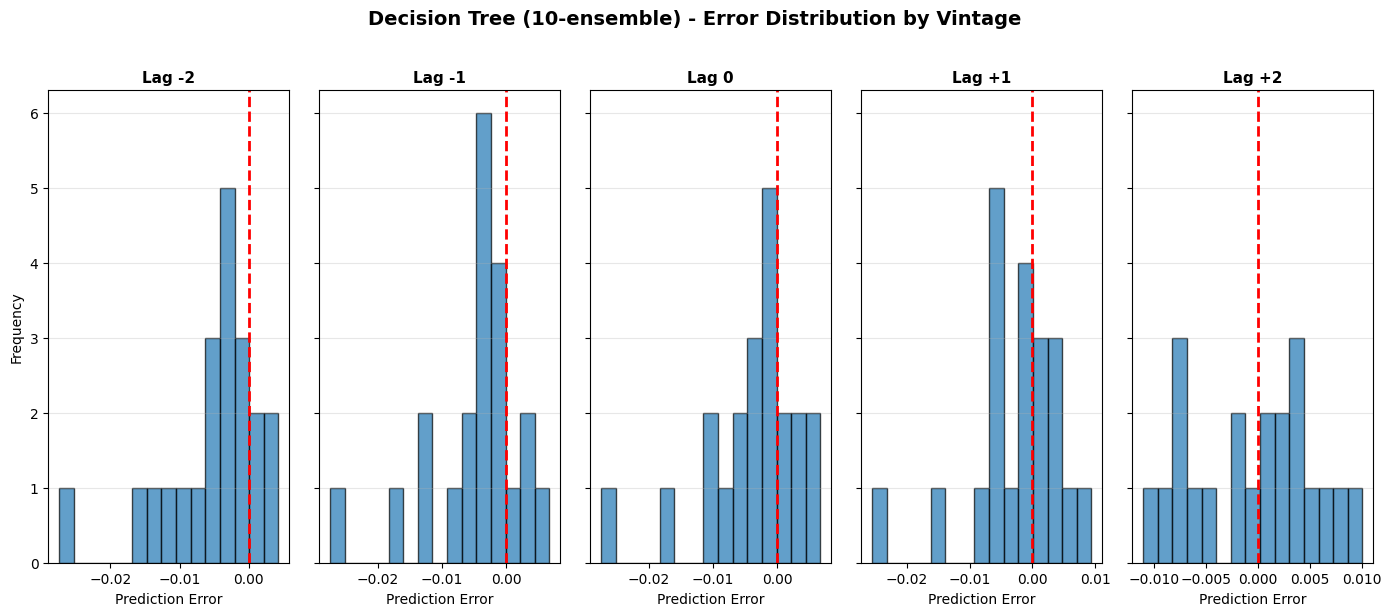

In [7]:
# Plot error distribution
fig2 = viz.plot_error_distribution('Decision Tree (10-ensemble)')
plt.show()

## 6. Production Inference

In [8]:
# Create inference pipeline
inference = InferencePipeline(dt_model, data_manager, config)

# Predict future quarter
prediction = inference.predict_new_date("2010-06-01")

print("\nFUTURE PREDICTION:")
print("=" * 60)
for key, value in prediction.items():
    print(f"{key:20s}: {value}")


FUTURE PREDICTION:
target_date         : 2010-06-01
prediction          : 0.0096907230055982
target_variable     : gdpc1
n_models            : 10
model_class         : DecisionTreeRegressor


## Summary

This notebook implements Decision Tree regression for GDP nowcasting. Decision trees can be quite stochastic, so we average predictions from 10 different models to get more stable results. The model uses absolute error as the splitting criterion and allows trees to grow without depth limits, though we control overfitting through minimum sample requirements.

The framework handles the complexity of training multiple models at each time period and managing different data vintages, reducing the implementation to just a few configuration parameters and function calls.